In [1]:
import os
import pandas as pd
import json
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math 
import random 
import igraph as ig
import networkx as nx
from math import log
import pickle
import gzip
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import copy
from functools import partial
from platform import system
import sys 
from pathlib import Path 

import 

In [3]:

ROOT = Path(__file__).resolve().parents[1] if "__file__" in globals() else Path.cwd().parents[0]
SRC  = ROOT / "src"
DATA = ROOT / "data"
FIGS = ROOT / "figures"

print("Project root:", ROOT)
print("Data folder:", DATA)
print("Figures folder:", FIGS)

sys.path.insert(0, str(SRC))
from utils import * 
from polarization_metrics import *

with gzip.open(DATA / "user_normalization_dict.json.gz", "rt", encoding="utf-8") as f:
    user_normalization_dict_loaded = json.load(f)
user_normalization_dict_loaded = {int(k): v for k, v in user_normalization_dict_loaded.items()}
print("🔁 Ricaricato, chiavi:", list(user_normalization_dict_loaded.keys())[:5])

with open(DATA / 'ActiveUsers_perSubreddit.pkl', 'rb') as f:
    ActiveUsers_perSubreddit = pickle.load(f)
print("🔁 Ricaricato ActiveUsers_perSubreddit, chiavi:", list(ActiveUsers_perSubreddit.keys()))
print("Esempio:", list(ActiveUsers_perSubreddit[2013].items())[:5])


csvdf2 = pd.read_csv(DATA / 'Subreddit_Tags.csv', sep=';', index_col=False)
Color_Field_df = pd.read_csv(DATA / 'Tag_Color.csv')


DizValTag = {} 

for i in range(len(csvdf2)) : 
    nome=csvdf2['subreddit'][i]
    n = 0
    for col in csvdf2.columns : 
        if col != 'subreddit' : 
            if csvdf2[col][i] != 0 : 
                n += 1 
    for col in csvdf2.columns : 
        if col != 'subreddit' : 
            if csvdf2[col][i] == 1 : 
                DizValTag[col+"_"+nome] = (1.0/n)
print(len(DizValTag)) 
print(DizValTag)

Project root: /Users/Daniele/Downloads/PolitoSphere Finale (Postzip)
Data folder: /Users/Daniele/Downloads/PolitoSphere Finale (Postzip)/data
Figures folder: /Users/Daniele/Downloads/PolitoSphere Finale (Postzip)/figures
🔁 Ricaricato, chiavi: [0, 1, 2, 3, 4]
🔁 Ricaricato ActiveUsers_perSubreddit, chiavi: [2013, 2014, 2015, 2016, 2017]
Esempio: [('politics', 271582), ('Economics', 17282), ('PoliticalDiscussion', 14679), ('Anarcho_Capitalism', 6247), ('Objectivism', 790)]
715
{'Dem_2012Elections': 0.5, 'Cons_2012Elections': 0.5, 'Dem_2016Elections': 0.5, 'Cons_2016Elections': 0.5, 'Dem_2016_elections': 0.5, 'Cons_2016_elections': 0.5, 'Lib_2ALiberals': 0.5, 'Gun_2ALiberals': 0.5, 'Politic_AOC': 0.5, 'Dem_AOC': 0.5, 'SocialJustice_Abortiondebate': 1.0, 'Geop_ActiveMeasures': 0.5, 'News_ActiveMeasures': 0.5, 'SocialJustice_AgainstHateSubreddits': 1.0, 'Ban_AgainstTheChimpire': 1.0, 'Econ_Agorism': 1.0, 'Canada_Albertapolitics': 1.0, 'Dem_AlexandriaOcasio': 1.0, 'Ban_AltRightChristian': 1.0

Subreddit and users processing

In [4]:
subinanno_2013 = [sub for sub, _ in ActiveUsers_perSubreddit[2013].items()]
print(f"Subreddits in 2013 validated network: {len(subinanno_2013)}")
TAGS = list(csvdf2.columns[1:])
tag_idx = {tag: i for i, tag in enumerate(TAGS)}
print(f"Tags: {TAGS}")
valori_normtag_valid = {tag: 0 for tag in TAGS}
TagvaluesPerYear = {tag: [] for tag in TAGS}

for tag in TAGS:
    for sub in subinanno_2013:
        key = f"{tag}_{sub}"
        if key in DizValTag:
            TagvaluesPerYear[tag].append(sub)
            valori_normtag_valid[tag] += DizValTag[key]

print(f"Tag coverage (nonzero tags): {sum(v != 0 for v in valori_normtag_valid.values())}/{len(TAGS)}")


Subreddits in 2013 validated network: 214
Tags: ['Geop', 'News', 'Far-Left', 'Econ', 'PolTalk', 'Politic', 'Dem', 'Lib', 'Cons', 'Gun', 'Far-Right', 'Ban', 'SocialJustice', 'UK', 'Eur', 'Canada', 'Austr']
Tag coverage (nonzero tags): 17/17


polarization matrix

In [5]:
results_2013 = compute_polarization_matrix(
    user_data=user_normalization_dict_loaded[0],
    TAGS=TAGS,
    tag_idx=tag_idx,
    valori_normtag_valid=valori_normtag_valid,
    TagvaluesPerYear=TagvaluesPerYear,
    year_label=2013
)

IndexPolarizationNORMALIZED = results_2013["IndexPolarizationNORMALIZED"]


Computing polarization (2013): 100%|██████████| 387691/387691 [01:44<00:00, 3705.58it/s]


✅ Processed 387691 users (387691 active)
Polarization matrix shape: (17, 17)


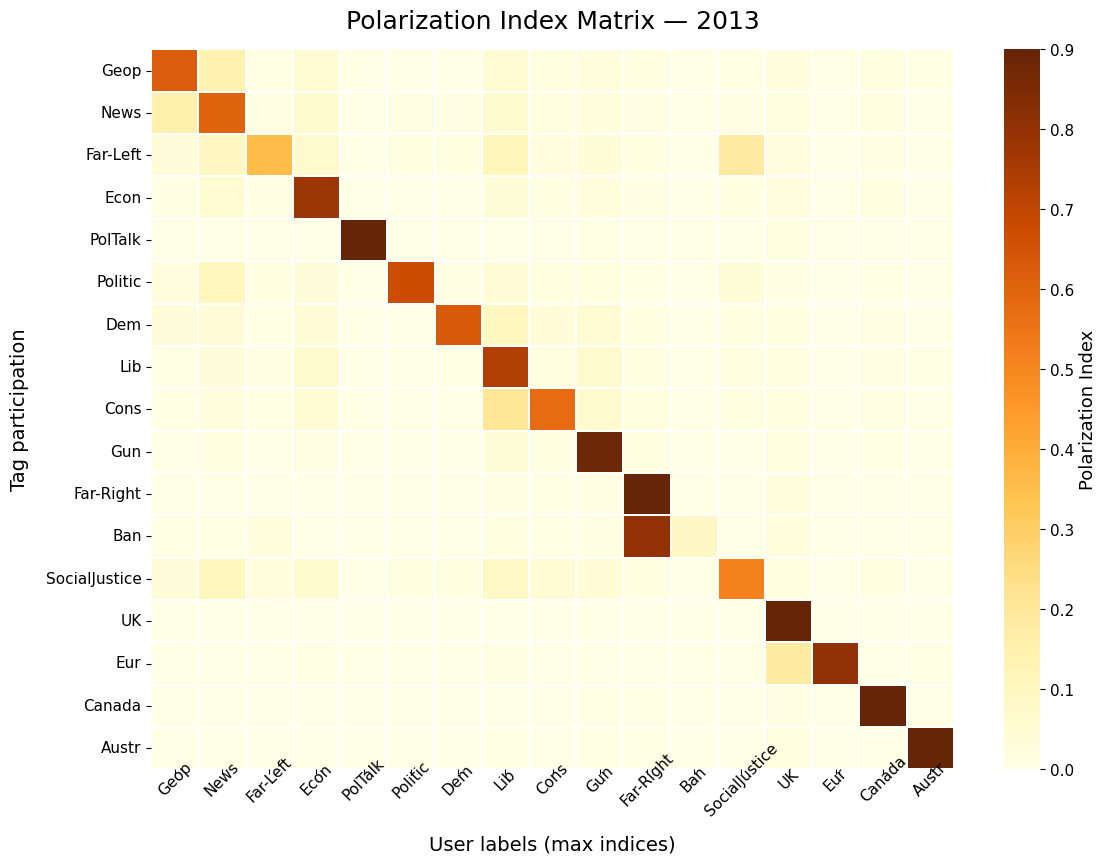

In [ ]:
vmin, vmax = 0, 0.9
anno = 2013

fig, ax = plt.subplots(figsize=(12, 9))

hm = sns.heatmap(
    IndexPolarizationNORMALIZED,
    ax=ax,
    cmap="YlOrBr",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Polarization Index"},
    vmin=vmin,
    vmax=vmax,
)

# === Titoli e label ===
ax.set_xlabel("User labels (max indices)", fontsize=14, labelpad=12)
ax.set_ylabel("Tag participation", fontsize=14, labelpad=12)

# Centra perfettamente le etichette sugli assi
ax.set_xticks([i + 0.5 for i in range(len(TAGS))])
ax.set_xticklabels(TAGS, rotation=45, ha="center", va="center", fontsize=11, color="black")

ax.set_yticks([i + 0.5 for i in range(len(TAGS))])
ax.set_yticklabels(TAGS, rotation=0, ha="right", va="center", fontsize=11, color="black")

# Colorbar
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=11)
cbar.set_label("Polarization Index", fontsize=13)

# Titolo
ax.set_title("Polarization Index Matrix — 2013", fontsize=18, pad=15)

plt.tight_layout(pad=2.0)
#plt.savefig(FIGS/ "Polarization_Matrix_2013.png", dpi=300)
plt.show()
